# Canteen Management system

In [56]:
!pip install openpyxl

In [57]:
import json
import pandas as pd

# Load JSON
with open("./assets/Canteen/canteen-management.json", "r") as f:
    data = json.load(f)

# Items table
items = []
for pid, p in data.get("products", {}).items():
    items.append({
        "item_id": p.get("id", pid),
        "name": p.get("name"),
        "price": p.get("price"),
        "initial_price": p.get("initialPrice") or p.get("initialPrices"),
        "stock_quantity": p.get("quantity")
    })

df_items = pd.DataFrame(items)

# Users table
users = {}
for date, sales in data.get("sales", {}).items():
    for sid, s in sales.items():
        uid = s.get("userId")
        if uid and uid not in users:
            users[uid] = {
                "user_id": uid,
                "email": s.get("userEmail")
            }

df_users = pd.DataFrame(users.values())

# Sales table (fact table)
sales_rows = []
for date, sales in data.get("sales", {}).items():
    for sid, s in sales.items():
        if "items" in s:
            for it in s["items"]:
                sales_rows.append({
                    "sale_id": sid,
                    "date": date,
                    "user_id": s.get("userId"),
                    "item_id": it.get("id"),
                    "quantity_sold": it.get("quantity", 0),
                    "unit_price": it.get("price", 0),
                    "line_total": it.get("quantity", 0) * it.get("price", 0),
                    "bill_total": s.get("total")
                })

df_sales = pd.DataFrame(sales_rows)

# Join: sales + users
df_sales_users = pd.merge(
    df_sales,
    df_users,
    on="user_id",
    how="left"
)

# Join: + items
df_full = pd.merge(
    df_sales_users,
    df_items,
    on="item_id",
    how="left",
    suffixes=("_sale", "_item")
)

# Write Excel
path = "./assets/Canteen/canteen_database.xlsx"
with pd.ExcelWriter(path, engine="openpyxl") as writer:
    df_items.to_excel(writer, sheet_name="items", index=False)
    df_users.to_excel(writer, sheet_name="users", index=False)
    df_sales.to_excel(writer, sheet_name="sales", index=False)
    df_full.to_excel(writer, sheet_name="sales_full", index=False)

print(f"Excel database created at: {path}")


Excel database created at: ./assets/Canteen/canteen_database.xlsx


In [58]:
# create username column in users and sales_full table
df_users["username"] = df_users["email"].apply(lambda x: x.split("@")[0] if pd.notnull(x) else None)
df_full["username"] = df_full["email"].apply(lambda x: x.split("@")[0] if pd.notnull(x) else None)
# Update the Excel file with the new users table
with pd.ExcelWriter(path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_users.to_excel(writer, sheet_name="users", index=False)
    df_full.to_excel(writer, sheet_name="sales_full", index=False)
print("Username column added to users and sales_full tables and Excel file updated.")

Username column added to users and sales_full tables and Excel file updated.


In [59]:
# rename name to item_name in sales_full and items table
df_full.rename(columns={"name": "item_name"}, inplace=True)
df_items.rename(columns={"name": "item_name"}, inplace=True)
# Update the Excel file with the new sales_full and items table
with pd.ExcelWriter(path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    df_full.to_excel(writer, sheet_name="sales_full", index=False)
    df_items.to_excel(writer, sheet_name="items", index=False)
print("Column 'name' renamed to 'item_name' in sales_full and items tables and Excel file updated.")

Column 'name' renamed to 'item_name' in sales_full and items tables and Excel file updated.


In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Read Excel
path = "./assets/Canteen/canteen_database.xlsx"
df = pd.read_excel(path, sheet_name="sales_full")

# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"])

In [61]:
# 1. Best selling item (by quantity sold)
best_selling = (
    df.groupby("item_name")["quantity_sold"]
    .sum()
    .sort_values(ascending=False)
)

print("Best selling items:")
print(best_selling.head(1))

Best selling items:
item_name
Sandwich    205
Name: quantity_sold, dtype: int64


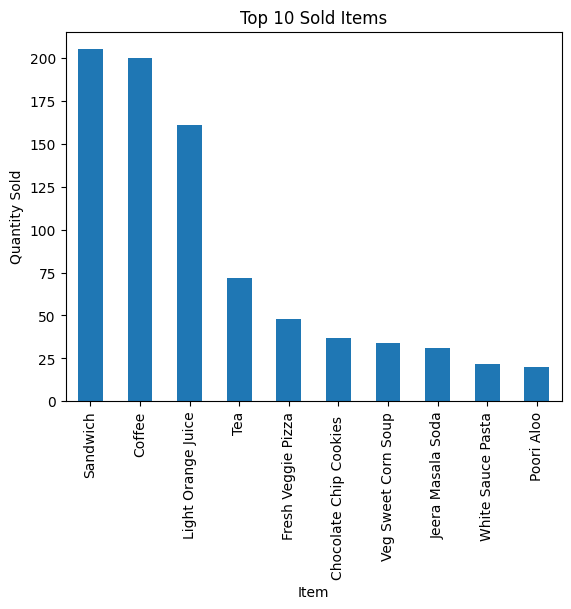

item_name
Sandwich                   205
Coffee                     200
Light Orange Juice         161
Tea                         72
Fresh Veggie Pizza          48
Chocolate Chip Cookies      37
Veg Sweet Corn Soup         34
Jeera Masala Soda           31
White Sauce Pasta           22
Poori Aloo                  20
Name: quantity_sold, dtype: int64


In [62]:
# 2. Top 10 sold items
plt.figure()
best_selling.head(10).plot(kind="bar")
plt.title("Top 10 Sold Items")
plt.ylabel("Quantity Sold")
plt.xlabel("Item")
plt.show()

print(best_selling.head(10))

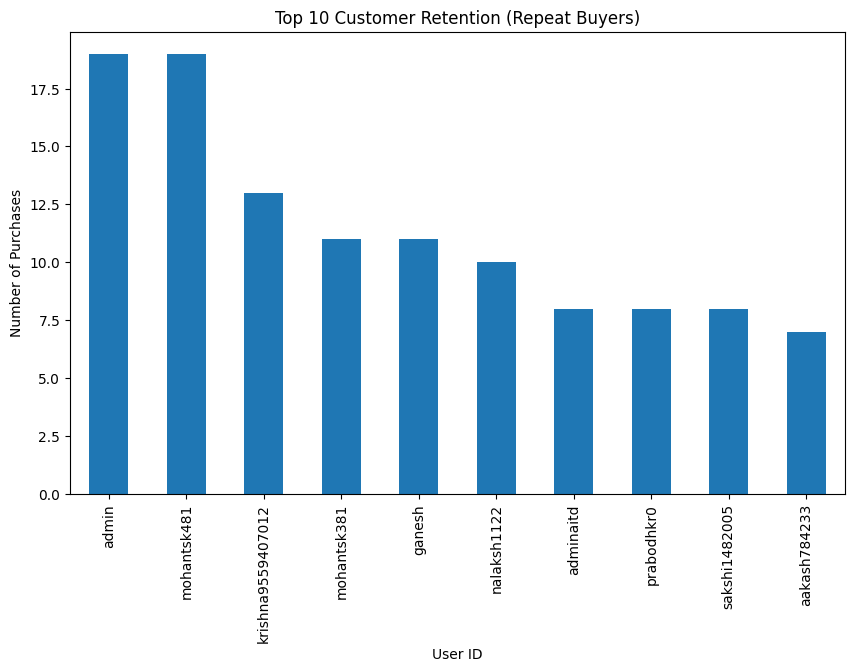


Repeat customers:
username
admin                19
mohantsk481          19
krishna9559407012    13
mohantsk381          11
ganesh               11
nalaksh1122          10
adminaitd             8
prabodhkr0            8
sakshi1482005         8
aakash784233          7
Name: sale_id, dtype: int64


In [63]:
# 3. Customer retention
# Users who purchased more than once
user_purchase_count = df.groupby("username")["sale_id"].nunique()
retained_users = user_purchase_count[user_purchase_count > 1]

# Get top 10 users by purchase count
top_10_retained = retained_users.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_retained.plot(kind="bar")
plt.title("Top 10 Customer Retention (Repeat Buyers)")
plt.ylabel("Number of Purchases")
plt.xlabel("User ID")
plt.show()

print("\nRepeat customers:")
print(retained_users.sort_values(ascending=False).head(10))

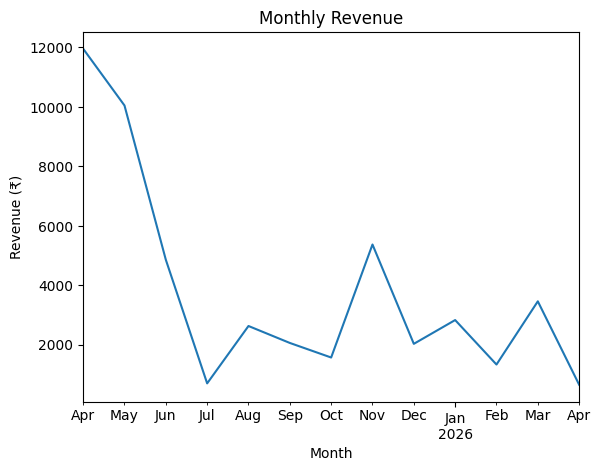


Monthly revenue:
month
2025-04    11951
2025-05    10042
2025-06     4854
2025-07      695
2025-08     2625
2025-09     2055
2025-10     1565
2025-11     5366
2025-12     2025
2026-01     2825
2026-02     1329
2026-03     3455
2026-04      650
Freq: M, Name: Monthly Revenue, dtype: int64


In [64]:
# 4. Monthly revenue
df["month"] = df["date"].dt.to_period("M")
monthly_revenue = df.groupby("month")["line_total"].sum()

monthly_revenue.name = "Monthly Revenue"

plt.figure()
monthly_revenue.plot(kind="line")
plt.title("Monthly Revenue")
plt.ylabel("Revenue (₹)")
plt.xlabel("Month")
plt.show()

print("\nMonthly revenue:")
print(monthly_revenue)

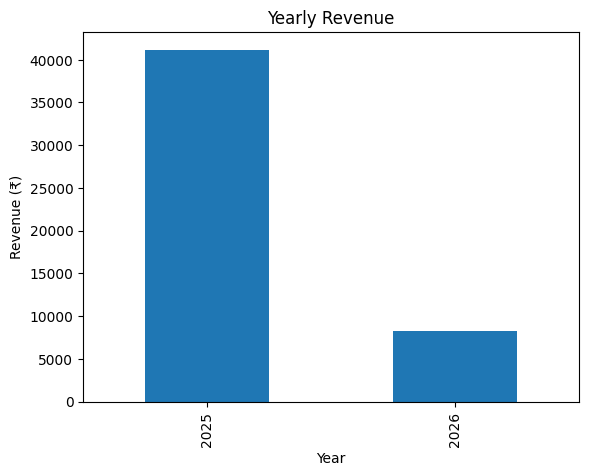


Yearly revenue:
year
2025    41178
2026     8259
Name: Yearly Revenue, dtype: int64


In [65]:
# 5. Yearly revenue
df["year"] = df["date"].dt.year
yearly_revenue = df.groupby("year")["line_total"].sum()

yearly_revenue.name = "Yearly Revenue"

plt.figure()
yearly_revenue.plot(kind="bar")
plt.title("Yearly Revenue")
plt.ylabel("Revenue (₹)")
plt.xlabel("Year")
plt.show()

print("\nYearly revenue:")
print(yearly_revenue)

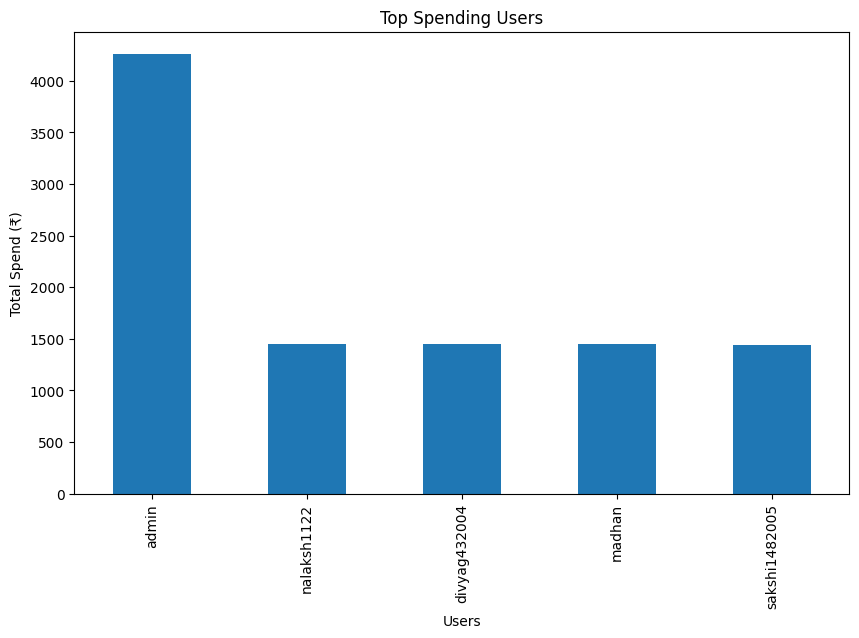


Top spending user:
username
admin            4263
nalaksh1122      1452
divyag432004     1450
madhan           1445
sakshi1482005    1435
Name: Total Spend, dtype: int64


In [66]:
# 6. User who bought the most (total spend)
top_user = (
    df.groupby("username")["line_total"]
    .sum()
    .sort_values(ascending=False)
)

top_user.name = "Total Spend"

plt.figure(figsize=(10, 6))
top_user.head(5).plot(kind="bar")
plt.title("Top Spending Users")
plt.ylabel("Total Spend (₹)")
plt.xlabel("Users")
plt.show()

print("\nTop spending user:")
print(top_user.head(5))


Customers who bought the same item multiple times:
item_name                             username         
Chilly Potato                         mohantsk381          3
Chocolate Chip Cookies                krishna9559407012    6
                                      sakshi1482005        2
Coffee                                1234                 2
                                      aadarshsavle         2
                                                          ..
Veg Darjeeling Steam Momo             test123456789        2
Veg Schezwan Noodles - Half (500 ml)  admin                2
Veg Sweet Corn Soup                   logo                 2
                                      mohantsk381          2
White Sauce Pasta                     mohantsk481          2
Name: sale_id, Length: 77, dtype: int64


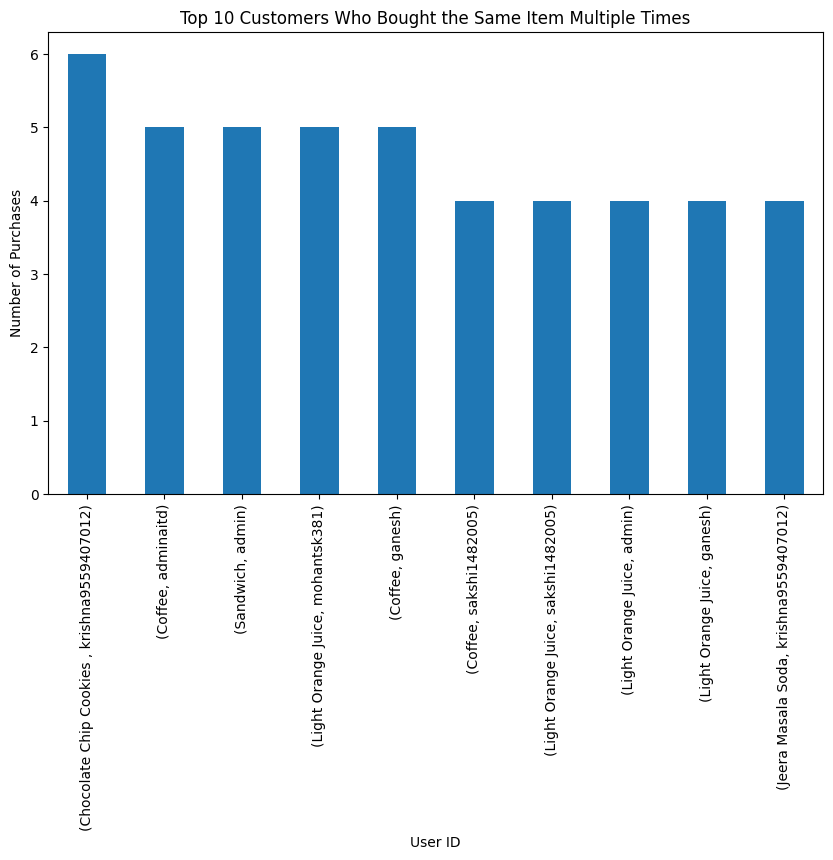

In [67]:
# cutomers who bought the same items twice or more
item_user = df.groupby(["item_name", "username"])["sale_id"].nunique()
repeated_customers = item_user[item_user > 1]
print("\nCustomers who bought the same item multiple times:")
print(repeated_customers)

# Get top 10 users by purchase count
top_10_retained = repeated_customers.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_retained.plot(kind="bar")
plt.title("Top 10 Customers Who Bought the Same Item Multiple Times")
plt.ylabel("Number of Purchases")
plt.xlabel("User ID")
plt.show()